In [8]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    KFold,
    LeaveOneOut,
    LeavePOut,
    StratifiedKFold,
    RepeatedKFold
)

In [7]:
x,y = load_breast_cancer(return_X_y=True,as_frame = True)
y = y.map({1:0,0:1})
x.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [9]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3,random_state=0)
x_train.shape,x_test.shape

((398, 30), (171, 30))

In [27]:
logit = LogisticRegression(penalty = 'l2',C= 1,solver = 'liblinear',random_state=4,max_iter=10000)
kf = KFold(n_splits = 5, shuffle=True,random_state=4)
param_grid = dict(
    penalty = ['l1','l2'],#if penalty is high, it will take weight into consideration
    C = [0.1,0.5,1,2]
)
clf  = GridSearchCV(logit,param_grid,cv = kf,scoring = 'accuracy',refit=True)#REFIT - it trains itself after finding best values

**Logistic Regression** - linear model used for binary classification.

**penalty = 'l2'** - Specifies the type of regularization to use. 'l2' (L2 regularization) adds a penalty equal to the square of the magnitude of coefficients. This helps prevent overfitting by discouraging very large weights.

**C = 1** This is the inverse of the regularization strength. Smaller values of C specify stronger regularization. Here, C=1 means a moderate regularization strength.

**solver = 'liblinear'** Specifies the algorithm to use for optimization. 'liblinear' is a good choice for smaller datasets and for l1 and l2 penalties.

**random_state = 4** This sets the seed for the random number generator used by the solver. This ensures reproducibility of your results, meaning you'll get the same outcome every time you run the code with this random_state.

**max_iter = 10000** Sets the maximum number of iterations for the solver to converge. If the solver doesn't converge within this many iterations, it will stop.

**n_splits = 5** Specifies that the dataset will be split into 5 folds. In 5-fold cross-validation, the data is divided into 5 equal parts. The model is trained 5 times; in each iteration, one fold is used as the test set, and the remaining 4 folds are used as the training set.

**shuffle = True** Before splitting, the data will be shuffled randomly. This is important to ensure that the folds are representative of the entire dataset and to prevent any bias due to the order of the data.

**estimator = logit** The LogisticRegression model that you want to tune.

**param_grid = param_grid** The dictionary defining the hyperparameter values to search.

**cv = kf** The cross-validation strategy to use (in this case, your KFold object). GridSearchCV will perform a cross-validation for each combination of hyperparameters in param_grid.

**scoring = 'accuracy'** The metric used to evaluate the performance of the model during cross-validation. accuracy is a common metric for classification tasks, representing the proportion of correctly classified instances.

**refit = True** After finding the best hyperparameters based on cross-validation, GridSearchCV will retrain the entire model on the full training dataset using these best parameters. This is typically what you want, as it gives you a final model trained on all available data.

In [28]:
search = clf.fit(x_train,y_train)
search.best_params_

{'C': 2, 'penalty': 'l1'}

In [29]:
result = pd.DataFrame(search.cv_results_)[['params','mean_test_score','std_test_score']]
print(result.shape)
result

(8, 3)


,params,mean_test_score,std_test_score
0,"{'C': 0.1, 'penalty': 'l1'}",0.919620,0.012606
1,"{'C': 0.1, 'penalty': 'l2'}",0.934747,0.019812
2,"{'C': 0.5, 'penalty': 'l1'}",0.942278,0.026821
3,"{'C': 0.5, 'penalty': 'l2'}",0.944810,0.024360
4,"{'C': 1, 'penalty': 'l1'}",0.944810,0.024360
5,"{'C': 1, 'penalty': 'l2'}",0.944778,0.025651
6,"{'C': 2, 'penalty': 'l1'}",0.947278,0.014460
7,"{'C': 2, 'penalty': 'l2'}",0.939747,0.022839


Based on these results, {'C': 2, 'penalty': 'l1'} appears to be the best-performing set of hyperparameters in terms of both high average accuracy and low variability.

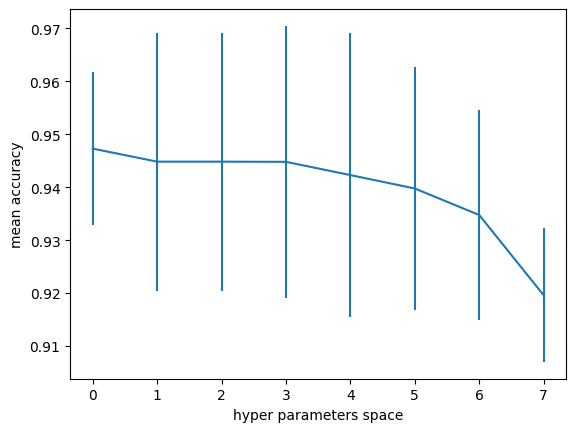

In [30]:
import matplotlib.pyplot as plt
result.sort_values(by = 'mean_test_score',ascending = False,inplace=True)
result.reset_index(inplace=True,drop=True)
result['mean_test_score'].plot(yerr = [result['std_test_score'],result['std_test_score']],subplots = True)
plt.ylabel('mean accuracy')
plt.xlabel('hyper parameters space')
plt.show()

This line sorts your result DataFrame based on the mean_test_score in descending order. The best performing hyperparameter combinations (highest mean accuracy) will be at the top of the DataFrame.

reset_index  - resets the DataFrame's index to a new, clean 0-based integer index after sorting. drop=True prevents the old index from being added as a new column.

**yerr = [results['std_test_score'], results['std_test_score']]** This is crucial for visualizing the standard deviation. It tells plot() to add error bars to each point on the line.


In [31]:
train_pred = search.predict(x_train)
test_pred = search.predict(x_test)
print('training accuracy',accuracy_score(y_train,train_pred))
print('test accuracy',accuracy_score(y_test,test_pred))

training accuracy 0.9597989949748744
test accuracy 0.9532163742690059


The strength of K-Fold: It ensures that every data point gets to be in the test set exactly once, and the model is trained on multiple different subsets of the data.

The limitation of K-Fold: Even with shuffling, a single run of K-Fold can still be sensitive to the specific random split of the data into folds. If you run it again with a different random_state (or no random_state), you might get slightly different average performance scores. This "noise" in the estimate can be a concern, especially with smaller datasets.

**Repeated K-Fold Cross-Validation**
addresses this limitation by simply repeating the entire K-Fold cross-validation procedure multiple times.

In [32]:
logit = LogisticRegression(penalty = 'l2',C = 1,solver = 'liblinear',random_state=4,max_iter = 1000)
kf = RepeatedKFold(n_splits = 5,n_repeats = 10,random_state=4)
param_grid = dict(
    penalty = ['l1','l2'],
    C = [0.1,0.5,1,10]
)
clf = GridSearchCV(logit,param_grid,cv = kf,scoring = 'accuracy',refit = True)
search = clf.fit(x_train,y_train)
search.best_params_

{'C': 10, 'penalty': 'l1'}

In [33]:
result = pd.DataFrame(search.cv_results_)[['params','mean_test_score','std_test_score']]
print(result.shape)
result

(8, 3)


,params,mean_test_score,std_test_score
0,"{'C': 0.1, 'penalty': 'l1'}",0.922820,0.022496
1,"{'C': 0.1, 'penalty': 'l2'}",0.932896,0.021612
2,"{'C': 0.5, 'penalty': 'l1'}",0.942196,0.021805
3,"{'C': 0.5, 'penalty': 'l2'}",0.941965,0.021726
4,"{'C': 1, 'penalty': 'l1'}",0.948497,0.021488
5,"{'C': 1, 'penalty': 'l2'}",0.945465,0.023291
6,"{'C': 10, 'penalty': 'l1'}",0.955025,0.023470
7,"{'C': 10, 'penalty': 'l2'}",0.951509,0.024498


Text(0, 0.5, 'hyper parameter space')

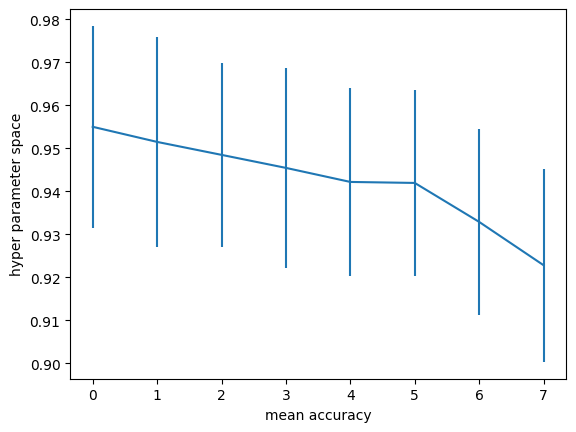

In [34]:
result.sort_values(by = 'mean_test_score',ascending = False,inplace = True)
result.reset_index(inplace = True,drop = True)
result['mean_test_score'].plot(yerr=[result['std_test_score'],result['std_test_score']],subplots= True)
plt.xlabel('mean accuracy')
plt.ylabel('hyper parameter space')

In [37]:
train_pred = search.predict(x_train)
test_pred = search.predict(x_test)
print('train accuracy',accuracy_score(y_train,train_pred))
print('test accuracy',accuracy_score(y_test,test_pred))

train accuracy 0.9748743718592965
test accuracy 0.9707602339181286


**"Leave-One-Out" (LOO)** cross-validation is a specific and exhaustive form of K-Fold cross-validation where the number of folds, k, is set equal to the total number of data points, n, in your dataset.

In [39]:
#leave one out
logit = LogisticRegression(C = 1,solver = 'liblinear',penalty = 'l2',max_iter = 10000,random_state = 4)
loo = LeaveOneOut()
param_grid = dict(
    penalty = ['l1','l2'],
    C = [0.1,0.5,1,2]
)
clf = GridSearchCV(logit,param_grid,cv = loo,scoring = 'accuracy',refit = True)
search = clf.fit(x_train,y_train)
search.best_params_

{'C': 2, 'penalty': 'l2'}

(8, 3)
                        params  mean_test_score  std_test_score
0  {'C': 0.1, 'penalty': 'l1'}         0.927136        0.259914
1  {'C': 0.1, 'penalty': 'l2'}         0.934673        0.247101
2  {'C': 0.5, 'penalty': 'l1'}         0.942211        0.233344
3  {'C': 0.5, 'penalty': 'l2'}         0.944724        0.228519
4    {'C': 1, 'penalty': 'l1'}         0.949749        0.218463
5    {'C': 1, 'penalty': 'l2'}         0.947236        0.223562
6    {'C': 2, 'penalty': 'l1'}         0.947236        0.223562
7    {'C': 2, 'penalty': 'l2'}         0.952261        0.213213


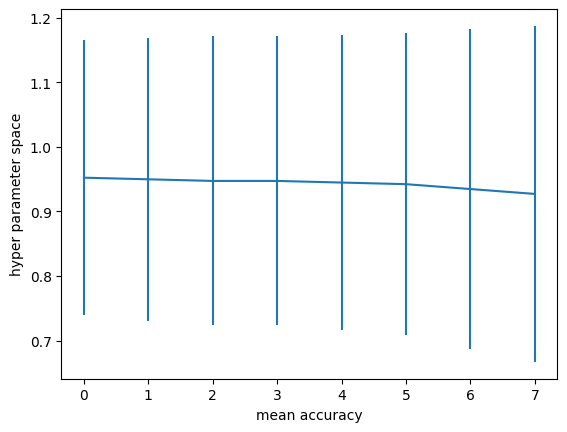

In [41]:
result = pd.DataFrame(search.cv_results_)[['params','mean_test_score','std_test_score']]
print(result.shape)
print(result)
result.sort_values(by = 'mean_test_score',ascending = False,inplace = True)
result.reset_index(inplace = True,drop = True)
result['mean_test_score'].plot(yerr = [result['std_test_score'],result['std_test_score']],subplots = True)
plt.xlabel('mean accuracy')
plt.ylabel('hyper parameter space')
plt.show()

In [42]:
train_pred = search.predict(x_train)
test_pred = search.predict(x_test)
print('training accuracy',accuracy_score(y_train,train_pred))
print('test accuracy',accuracy_score(y_test,test_pred))

training accuracy 0.9547738693467337
test accuracy 0.9590643274853801


LPO is an exhaustive cross-validation method. It creates all possible ways to split the dataset into a training set and a test set, where the test set always consists of exactly p samples.

When to use LPO:

Extremely small datasets: Where n is very low (e.g., < 20-30 samples), and p is also small, making the combinatorial explosion manageable.

When a highly precise (low bias) estimate is absolutely critical: And you have the computational resources to spare.

Specific research scenarios: Where understanding every possible split is required, or for specific theoretical analyses.

Leave-One-Out (p=1) is a common special case: It minimizes bias and is sometimes used for very small datasets, but still faces the high variance issue.

In [45]:
#leave P Out
logit = LogisticRegression(penalty = 'l2',C = 1,solver = 'liblinear',max_iter = 10000,random_state = 4)

lpo = LeavePOut(p=2)

x_train_small = x_train.head(30)
y_train_small = y_train.head(30)
param_grid = dict(
    penalty = ['l1','l2'],
    C = [0.1,0.5,1,2]
    )

clf = GridSearchCV(logit,param_grid,cv = lpo,scoring = 'accuracy',refit = True)
search  = clf.fit(x_train_small,y_train_small)
search.best_params_

{'C': 0.1, 'penalty': 'l1'}

(8, 3)
                        params  mean_test_score  std_test_score
0  {'C': 0.1, 'penalty': 'l1'}         0.900000        0.208443
1  {'C': 0.1, 'penalty': 'l2'}         0.898851        0.209265
2  {'C': 0.5, 'penalty': 'l1'}         0.870115        0.226982
3  {'C': 0.5, 'penalty': 'l2'}         0.897701        0.210078
4    {'C': 1, 'penalty': 'l1'}         0.870115        0.226982
5    {'C': 1, 'penalty': 'l2'}         0.872414        0.225750
6    {'C': 2, 'penalty': 'l1'}         0.870115        0.226982
7    {'C': 2, 'penalty': 'l2'}         0.871264        0.226370


Text(0, 0.5, 'hyper parameter space')

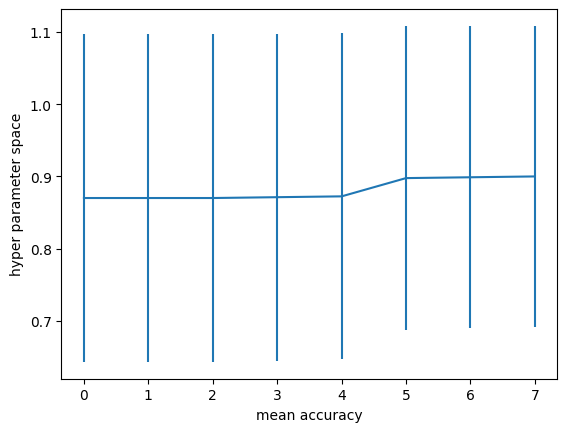

In [49]:
result = pd.DataFrame(search.cv_results_)[['params','mean_test_score','std_test_score']]
print(result.shape)
print(result)
result.sort_values(by = 'mean_test_score',inplace = True)
result.reset_index(inplace = True,drop = True)
result['mean_test_score'].plot(yerr = [result['std_test_score'],result['std_test_score']],subplots = True)
plt.xlabel('mean accuracy')
plt.ylabel('hyper parameter space')

In [48]:
train_pred = search.predict(x_train)
test_pred = search.predict(x_test)
print('train accuracy',accuracy_score(y_train,train_pred))
print('test accuracy',accuracy_score(y_test,test_pred))

train accuracy 0.9120603015075377
test accuracy 0.9239766081871345


Stratified K-Fold is a variation of K-Fold cross-validation designed to handle classification problems, especially those with imbalanced class distributions. It ensures that each fold (both training and test) maintains approximately the same proportion of samples for each class as the original dataset.

When to use Stratified K-Fold:

Almost always for classification problems: It's the recommended default for classification, even if you think your classes are balanced. It adds robustness without significant computational overhead.

Essential for imbalanced datasets: Where one or more classes have significantly fewer samples than others.

During hyperparameter tuning: It's well-suited for GridSearchCV or RandomizedSearchCV due to its balance of efficiency and robust evaluation.

In [50]:
#sratified K fold
logit = LogisticRegression(penalty = 'l2',solver = 'liblinear',C = 1,random_state = 4,max_iter = 10000)

# Remove the 'shuffle' argument
skf = StratifiedKFold(n_splits = 5,shuffle = True,random_state = 4) #used with imbalnced data.


#hyper parameter space
param_grid = dict(
    penalty = ['l1','l2'], # if penalty is high it will take weights to consideration
    C = [0.1,1,10]

)
#grid search cv
clf = GridSearchCV(
    logit,
    param_grid,
    scoring = 'accuracy',
    cv = skf,
    refit = True
    ) #REFIT - it trains itself after finding best values

search = clf.fit(x_train,y_train)
search.best_params_

{'C': 1, 'penalty': 'l1'}

(6, 3)
                        params  mean_test_score  std_test_score
0  {'C': 0.1, 'penalty': 'l1'}         0.927025        0.020516
1  {'C': 0.1, 'penalty': 'l2'}         0.926994        0.027246
2    {'C': 1, 'penalty': 'l1'}         0.949652        0.026659
3    {'C': 1, 'penalty': 'l2'}         0.944620        0.023649
4   {'C': 10, 'penalty': 'l1'}         0.947184        0.021802
5   {'C': 10, 'penalty': 'l2'}         0.949652        0.021315


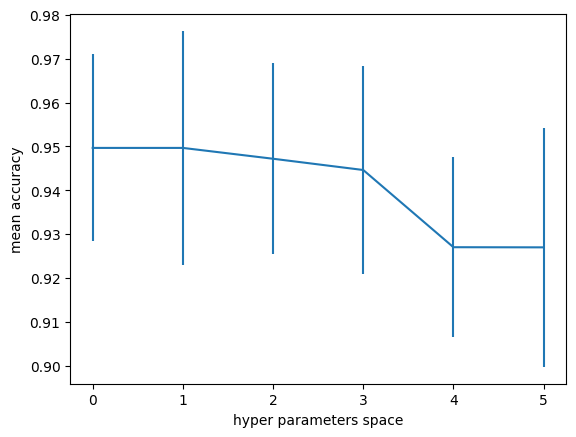

In [51]:
results = pd.DataFrame(search.cv_results_)[['params','mean_test_score','std_test_score']]
print(results.shape)
print(results)
results.sort_values(by = 'mean_test_score',ascending = False,inplace=True)
results.reset_index(inplace=True,drop=True)
results['mean_test_score'].plot(yerr = [results['std_test_score'],results['std_test_score']],subplots = True)
plt.ylabel('mean accuracy')
plt.xlabel('hyper parameters space')
plt.show()

In [53]:
train_pred = search.predict(x_train)
test_pred = search.predict(x_test)
print('train accuracy',accuracy_score(y_train,train_pred))
print('test accuracy',accuracy_score(y_test,test_pred)) #if we get same, model is good

train accuracy 0.9597989949748744
test accuracy 0.9649122807017544


You generally want to use Stratified K-Fold for almost all classification tasks because it's computationally efficient, provides robust estimates, and crucially, handles class imbalance gracefully.

Leave-P-Out is a specialized, computationally intensive method primarily reserved for very small datasets or situations where an exhaustive, low-bias estimate is paramount, and the computational cost is acceptable. Given the context of your previous errors with LeavePOut(p=2) on even 30 samples, it highlights its impracticality for typical machine learning workflows.